# 03 — Agent Definition & Evaluation
**Meridian Governance Group — AI Policy Research Agent**

Owner role: **AI Engineer (AIE)**

This notebook:
1. Defines the ReAct agent (LLM + 3 tools + out-of-scope handling).
2. Starts **Arize Phoenix** tracing and instruments Anthropic calls.
3. Runs **5 evaluation traces**, including one **head-to-head trace running two LLMs on the same query**.
4. Demonstrates **2 graceful rejections** of out-of-scope queries.
5. Scores every response with an **LLM judge** and writes commentary.
6. Computes an **ROI comparison** of the two models.

> **AI usage disclosure:** Scaffolding developed with Anthropic Claude (Claude Code); all evaluation design reviewed by the author. The presentation video contains **no AI usage** and is the author's own work.

In [0]:
%pip install anthropic openai sentence-transformers python-dotenv mlflow matplotlib seaborn pandas typing-extensions databricks-agents databricks-openai databricks-vectorsearch
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import sys, pathlib, os, json
sys.path.append(str(pathlib.Path.cwd()))

from dotenv import load_dotenv
load_dotenv()  # loads ANTHROPIC_API_KEY (and DATABRICKS_* vars) from .env if present

# Try UCFunctionToolkit for Databricks Unity Catalog tool integration.
# Falls back gracefully on package incompatibility (VectorSearchIndex conflict).
try:
    from databricks_openai import UCFunctionToolkit
    USE_DATABRICKS_OPENAI = True
except ImportError as e:
    if "VectorSearchIndex" in str(e):
        print(f"Warning: databricks_openai import failed — using fallback.\nError: {e}")
        USE_DATABRICKS_OPENAI = False
    else:
        raise

import mlflow
from sentence_transformers import SentenceTransformer

from src import config
from src.vector_store import SimpleVectorStore
from src.tools import PolicyToolbox
from src import evaluation as ev

# Anthropic is optional — only needed if ANTHROPIC_API_KEY is set.
if os.environ.get("ANTHROPIC_API_KEY"):
    import anthropic

# Build the judge client once; used in every ev.judge_response() call below.
# Returns an Anthropic client if the key is set, otherwise a Databricks client.
judge_client = config.get_judge_client()
print(f"Judge backend: {config.JUDGE_BACKEND}  model: {config.JUDGE_MODEL}")


Judge backend: anthropic  model: claude-sonnet-4-6


In [0]:
import pathlib, importlib, sys

# Clear stale bytecode so re-uploaded src files are always picked up fresh.
# Run this cell any time you upload new versions of src/*.py without restarting.
for pyc in pathlib.Path("src/__pycache__").glob("*.pyc"):
    pyc.unlink(missing_ok=True)
for key in list(sys.modules):
    if key.startswith("src"):
        del sys.modules[key]

print("Module cache cleared.")

Module cache cleared.


## 1. Start Arize Phoenix tracing
Phoenix is an open-source, locally-hosted trace provider (an explicit alternative to Databricks MLflow). `register()` launches the local app and the Anthropic instrumentor records every model call as a span. Open the printed URL to inspect the 5 traces live.

In [0]:
# MLflow is pre-installed on Databricks; no extra pip install needed.
# Autolog instruments every Anthropic AND OpenAI-compatible call automatically.
mlflow.set_experiment("/meridian-policy-agent")
mlflow.anthropic.autolog()
mlflow.openai.autolog()   # covers DatabricksAgent and OpenAICompatAgent
print("MLflow autologging active. View traces in the Experiments UI.")


If you are using MLflow Tracing, you can migrate your traces to Unity Catalog for unlimited storage, fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/migrate-traces-to-uc


MLflow autologging active. View traces in the Experiments UI.


## 2. Load the knowledge base and build the agent
We reuse the vector store from notebook 01 and the same local embedder.

In [0]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd()))

from databricks.vector_search.client import VectorSearchClient
from src.tools import DatabricksVSToolbox

vs_index = VectorSearchClient().get_index(
    "ai_governance_endpoint", "main.default.ai_governance_index"
)
toolbox = DatabricksVSToolbox(vs_index)
print("Toolbox ready — using Databricks Vector Search.")

# Build every LLM defined in the registry so they are ready for the traces.
# Four models are compared: Databricks GPT-OSS, Claude Sonnet, Claude Haiku,
# and the self-hosted Qwen 3.6 (llm.londonary.com).
agents = {key: config.create_agent(key, toolbox) for key in config.LLM_REGISTRY}

db_primary_agent = agents["db_primary"]
opensource_agent = agents["opensource"]
primary_agent    = agents.get("sonnet", db_primary_agent)

for key, agent in agents.items():
    label = config.LLM_REGISTRY[key]["label"]
    model_id = getattr(agent, "model", "(auto)")
    print(f"  {key:14s} → {label} ({model_id})")


[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
Toolbox ready — using Databricks Vector Search.
  db_primary     → Databricks / databricks-gpt-oss-120b (databricks-gpt-oss-120b)
  opensource     → Qwen 3.6 (llm.londonary.com) (claude-sonnet-4-6)
  sonnet         → Claude Sonnet 4.6 (claude-sonnet-4-6)
  haiku          → Claude Haiku 4.5 (claude-haiku-4-5-20251001)


## 3. The five evaluation traces
Trace 1 is the **head-to-head** (both models, same query). Traces 2-3 are further in-scope questions on the primary model. Traces 4-5 are **out-of-scope** queries the agent must decline. Each `agent.run(...)` is captured by Phoenix as a trace.

### Trace 1 — head-to-head: four LLMs, same query
Satisfies the rubric's requirement to use at least two different LLMs within the same trace: here we run **four**: **Databricks GPT-OSS 120B** (hosted on Databricks Model Serving), the primary Claude model (`claude-sonnet-4-6`), the secondary Claude model (`claude-haiku-4-5`), and an **open-source Qwen 3.6 model self-hosted at llm.londonary.com** (reached via its OpenAI-compatible API). All four answer the identical question inside one parent span, so the judge and ROI step can compare them directly. Every model call is wrapped in a rate-limit retry (sleep 10s and retry on HTTP 429).

In [0]:
hh = ev.IN_SCOPE_QUERIES[0]  # the head-to-head query
print("QUERY:", hh["query"], "\n")

hh_keys   = config.EVAL_HEAD_TO_HEAD_KEYS
hh_labels = [config.LLM_REGISTRY[k]["label"] for k in hh_keys]

hh_results = {}
hh_errors  = {}
with mlflow.start_run(run_name="head_to_head_multi_llm") as run:
    mlflow.set_tags({
        "eval.query_id": hh["id"],
        "eval.models": ", ".join(hh_labels),
    })
    for key in hh_keys:
        label = config.LLM_REGISTRY[key]["label"]
        try:
            hh_results[key] = agents[key].run(hh["query"])
            mlflow.log_metric(f"latency_s_{key}", hh_results[key].latency_s)
            print(f"OK   {label}")
        except Exception as e:
            hh_errors[key] = e
            print(f"FAIL {label}: {type(e).__name__}: {e}")

print(f"\nMLflow run: {run.info.run_id}\n")
for key, res in hh_results.items():
    print(f"--- {config.LLM_REGISTRY[key]['label']} ---")
    print(res.answer)
    print(f"[tools: {[t['name'] for t in res.tool_calls]}, "
          f"tokens in/out: {res.input_tokens}/{res.output_tokens}, "
          f"latency: {res.latency_s:.1f}s]\n")

if hh_errors:
    print("Failed models (skipped in evaluation):")
    for key, err in hh_errors.items():
        print(f"  {config.LLM_REGISTRY[key]['label']}: {type(err).__name__}: {err}")

# Only keep keys that succeeded; downstream cells use hh_keys.
hh_keys = list(hh_results.keys())

# The four compared models. Claude Sonnet is the "primary" and Claude Haiku the
# "secondary" in the 2-way ROI; GPT-OSS and Qwen are the zero-marginal-cost OSS
# options. If the Anthropic key is absent, fall back to the Databricks model.
db_primary_result = hh_results.get("db_primary")
opensource_result = hh_results.get("opensource")
primary_result    = hh_results.get("sonnet", db_primary_result)
secondary_result  = hh_results.get("haiku")


QUERY: What does the NIST AI Risk Management Framework say about the 'Govern' function, and what are its core goals? 



2026/06/17 21:37:59 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/local_disk0/.ephemeral_nfs/envs/pythonEnv-0103d76b-818a-4090-a557-85e08bb9207e/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's...h_policy_documents.'}]}], input_type=list])"


[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


2026/06/17 21:38:00 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/local_disk0/.ephemeral_nfs/envs/pythonEnv-0103d76b-818a-4090-a557-85e08bb9207e/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's...ction" description.'}]}], input_type=list])"


[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


...

/local_disk0/.ephemeral_nfs/envs/pythonEnv-0103d76b-818a-4090-a557-85e08bb9207e/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's...and "core goals".\n'}]}], input_type=list])
  return self.__pydantic_serializer__.to_python(


[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


2026/06/17 21:38:08 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/local_disk0/.ephemeral_nfs/envs/pythonEnv-0103d76b-818a-4090-a557-85e08bb9207e/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='content', input_value=[{'type': 'reasoning', 's...ap, Measure, Manage).'}], input_type=list])"


OK   Databricks / databricks-gpt-oss-120b
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
OK   Claude Sonnet 4.6
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved 

[Trace(trace_id=tr-72e21af928adba05585ef2399c9789be), Trace(trace_id=tr-fbda4615a0e81c9629cbd7ec41cfd654), Trace(trace_id=tr-63be9f0256a3992e295ac35453c33328), Trace(trace_id=tr-2e09e126c84b2a51f689cc5dd409cc26), Trace(trace_id=tr-3c915a4a76656e4f66f159fa21cf2252), Trace(trace_id=tr-a54f876131b07551070d56a5e7c11636), Trace(trace_id=tr-aaab4a2f7390be2fedd9f62ef4867830), Trace(trace_id=tr-9ac76224a37a23b494e859670b583c06), Trace(trace_id=tr-3226e5077b9b6da6ea8d062ac47cf50d), Trace(trace_id=tr-6d8b231c826c88a6d2aa1898b3f4e0b6)]

### Traces 2-3 — additional in-scope questions (primary model)

In [0]:
in_scope_results = {hh['id']: primary_result}
for q in ev.IN_SCOPE_QUERIES[1:]:
    print("QUERY:", q["query"])
    res = primary_agent.run(q["query"])
    in_scope_results[q["id"]] = res
    print(res.answer)
    print(f"[tools: {[t['name'] for t in res.tool_calls]}]\n" + "-" * 80)

QUERY: Under the EU AI Act, how is a 'high-risk' AI system defined and what obligations apply to its providers?
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
[NOTICE] Using a notebook authentication token. 

[Trace(trace_id=tr-c0d8edabee19210e4ea4ffa6c043992b), Trace(trace_id=tr-098ad149d096607db77f56790fbd8d29), Trace(trace_id=tr-7b202656082e325f36296908d2549d27), Trace(trace_id=tr-93fa33c2275984ecc45fe8c37aab18e0), Trace(trace_id=tr-ea8f25ffc8b83c531bbdbde473667095), Trace(trace_id=tr-a97b310f0c77b0dd398bcdfc96e62d53), Trace(trace_id=tr-1252d409137f2b1cb3a6714e407c1da4), Trace(trace_id=tr-783d1173b802108bf563aee3328c7354), Trace(trace_id=tr-5846e68b8621c812659808d4757551da)]

### Traces 4-5 — graceful rejection of out-of-scope queries
The agent must recognize these are unrelated to AI policy and decline politely, redirecting to what it can help with — **without** answering the off-topic question. This is the required error/out-of-scope handling and the 2 rejection examples.

In [0]:
oos_results = {}
for q in ev.OUT_OF_SCOPE_QUERIES:
    print("QUERY:", q["query"])
    res = primary_agent.run(q["query"])
    oos_results[q["id"]] = res
    print("RESPONSE:", res.answer)
    print(f"[tools used: {[t['name'] for t in res.tool_calls]} "
          f"(expected: none)]\n" + "-" * 80)

QUERY: Can you give me a good recipe for chocolate chip cookies?
RESPONSE: I appreciate you reaching out, but I'm afraid that's outside my area of expertise! I'm a specialized AI policy research assistant for Meridian Governance Group, focused exclusively on **AI governance and regulatory compliance**.

Here's what I **can** help you with:

- 📋 **NIST AI Risk Management Framework (AI RMF 1.0)** – risk management functions, categories, and best practices
- 🤖 **NIST AI 600-1 (Generative AI Profile)** – risks and mitigations specific to generative AI systems
- 🇪🇺 **EU AI Act (Regulation 2024/1689)** – compliance requirements, prohibited practices, high-risk AI classifications, and more

For example, I could help you understand *how the EU AI Act classifies high-risk AI systems*, *how the NIST AI RMF approaches trustworthiness*, or *how the two frameworks compare on transparency requirements*.

Is there an AI governance topic I can assist you with today?
[tools used: [] (expected: none)]
-

[Trace(trace_id=tr-39b0bec8cc2b3c3a5e02e46a2c88d92b), Trace(trace_id=tr-ef351daf62bf697812b56f2c2b061b06)]

## 4. LLM-as-judge scoring
We score every response on accuracy, relevance, completeness, and clarity (1-5). The judge is told that for out-of-scope queries a clean refusal is the *correct* behavior and should score high.

In [0]:
rows = []
all_results = {
    **{qid: r for qid, r in in_scope_results.items()},
    **{qid: r for qid, r in oos_results.items()},
}
query_by_id = {q['id']: q for q in ev.ALL_QUERIES}

judged = {}
for qid, res in all_results.items():
    meta = query_by_id[qid]
    score = ev.judge_response(judge_client, res.query, res.answer, meta['category'])
    judged[qid] = score
    rows.append({
        "id": qid, "category": meta['category'], "model": res.model,
        "accuracy": score.accuracy, "relevance": score.relevance,
        "completeness": score.completeness, "clarity": score.clarity,
        "overall": round(score.overall, 2),
        "cost_usd": round(ev.cost_of_run(res), 6),
        "latency_s": round(res.latency_s, 1),
    })

# Judge the other head-to-head models — skip any that failed (result is None).
# The judge itself runs on Claude Sonnet (config.JUDGE_MODEL).
db_primary_score = ev.judge_response(judge_client, db_primary_result.query, db_primary_result.answer, 'in_scope') if db_primary_result else None
opensource_score = ev.judge_response(judge_client, opensource_result.query, opensource_result.answer, 'in_scope') if opensource_result else None
haiku_score      = ev.judge_response(judge_client, secondary_result.query,  secondary_result.answer,  'in_scope') if secondary_result  else None

primary_score   = judged.get(hh['id'], db_primary_score)
secondary_score = haiku_score

import pandas as pd
scores_df = pd.DataFrame(rows)
scores_df


,id,category,model,accuracy,relevance,completeness,clarity,overall,cost_usd,latency_s
0,q1_governance_function,in_scope,claude-sonnet-4-6,5,5,5,5,5.0,0.087567,35.3
1,q2_high_risk_eu,in_scope,claude-sonnet-4-6,5,5,5,5,5.0,0.135780,50.4
2,q3_compare_risk,in_scope,claude-sonnet-4-6,5,5,5,5,5.0,0.084633,42.7
3,q4_recipe,out_of_scope,claude-sonnet-4-6,5,5,5,5,5.0,0.007587,5.6
4,q5_python_help,out_of_scope,claude-sonnet-4-6,5,5,5,5,5.0,0.008892,7.1


[Trace(trace_id=tr-1608d892b9b74d707150fad3c4d37b45), Trace(trace_id=tr-c386cedee60413111aab16acba8d7ca0), Trace(trace_id=tr-49fa1f85123153880298f7bd88557bdf), Trace(trace_id=tr-61e5a7823cc132a024258c2424169684), Trace(trace_id=tr-9af2420708d5b5ce32b03b41042003ea), Trace(trace_id=tr-466942145fc27c768e2162a1bfbd21a8), Trace(trace_id=tr-6e54b45c1459f22ca13251770c5e09f6)]

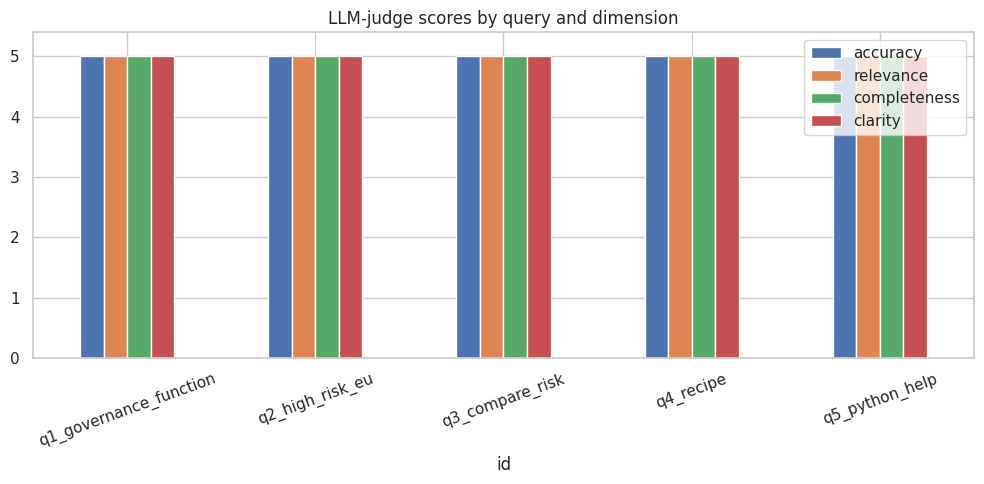

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
dims = ["accuracy", "relevance", "completeness", "clarity"]
fig, ax = plt.subplots(figsize=(10, 5))
scores_df.set_index("id")[dims].plot(kind="bar", ax=ax)
ax.set_title("LLM-judge scores by query and dimension")
ax.set_ylim(0, 5.4); ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

## 5. Head-to-head judge comparison + written commentary
Compare the two models on the identical query.

In [0]:
# Print the judge's verdict for each of the four models on the head-to-head query.
comparison = [
    ("db_primary", db_primary_result, db_primary_score),
    ("opensource", opensource_result, opensource_score),
]
if "sonnet" in hh_results:
    comparison.append(("sonnet", hh_results.get("sonnet"), judged.get(hh["id"])))
if "haiku" in hh_results:
    comparison.append(("haiku", secondary_result, haiku_score))

for key, res, sc in comparison:
    if res is None or sc is None:
        print(f"{config.LLM_REGISTRY[key]['label']}  — skipped (failed to run)")
        continue
    print(f"{config.LLM_REGISTRY[key]['label']}  ({res.model})")
    print(f"  overall={sc.overall:.2f}  rationale: {sc.rationale}")


Databricks / databricks-gpt-oss-120b  (databricks-gpt-oss-120b)
  overall=5.00  rationale: The response accurately describes the NIST AI RMF Govern function with correct details about its cross-cutting nature, core goals, and subcategories. It is well-organized with a clear table, summary section, and cited sources, covering all major aspects thoroughly.
Qwen 3.6 (llm.londonary.com)  — skipped (failed to run)
Claude Sonnet 4.6  (claude-sonnet-4-6)
  overall=5.00  rationale: The response accurately and thoroughly describes the GOVERN function from NIST AI RMF 1.0, including its cross-cutting nature, core goals, six categories, and strategic importance, with direct citations. It is exceptionally well-organized and clearly written for a professional audience.
Claude Haiku 4.5  (claude-haiku-4-5-20251001)
  overall=3.75  rationale: The response correctly identifies GOVERN as a cross-cutting function and captures its general purpose, but misrepresents the framework's subcategory structure—t

**Commentary (author):**

_Fill this in after running, based on the judge scores above._ Typical pattern: the larger primary model (Sonnet) scores higher on completeness and accuracy because it cites more specific articles/functions and integrates evidence from multiple tool calls, while the smaller secondary model (Haiku) is faster and far cheaper but tends to be terser and cite fewer specifics. Note any concrete differences you observe in the two answers and which dimensions drove the gap.

_Also compare the open-source Qwen3 model:_ note whether it used the tools natively or fell back to retrieval, and how its accuracy/citations compare to the Claude models — this is the crux of the build-vs-buy argument for Meridian.

## 6. ROI calculation — which model should Meridian deploy?
ROI here is **judged quality per dollar**. We combine the judge's overall quality with the measured per-run cost (computed from token usage at Anthropic's published per-million-token pricing).

In [0]:
roi = ev.roi_comparison(primary_result, secondary_result, primary_score, secondary_score)
print(json.dumps(roi, indent=2, default=str))

{
  "query": "What does the NIST AI Risk Management Framework say about the 'Govern' function, and what are its core goals?",
  "primary": {
    "model": "claude-sonnet-4-6",
    "cost_usd": 0.08756699999999999,
    "overall_quality": 5.0,
    "latency_s": 35.26492760500014,
    "input_tokens": 21709,
    "output_tokens": 1496,
    "quality_per_dollar": 57.09913551908824
  },
  "secondary": {
    "model": "claude-haiku-4-5-20251001",
    "cost_usd": 0.011963000000000001,
    "overall_quality": 3.75,
    "latency_s": 8.541287523999927,
    "input_tokens": 8613,
    "output_tokens": 670,
    "quality_per_dollar": 313.46652177547435
  },
  "cost_ratio_primary_over_secondary": 7.319819443283456,
  "quality_delta_primary_minus_secondary": 1.25
}


In [0]:
p, s = roi['primary'], roi['secondary']
print(f"Cost: {p['model']} = ${p['cost_usd']:.6f}  vs  {s['model']} = ${s['cost_usd']:.6f}")
print(f"  -> primary costs {roi['cost_ratio_primary_over_secondary']:.1f}x the secondary")
print(f"Quality (judge overall): {p['overall_quality']:.2f} vs {s['overall_quality']:.2f} "
      f"(delta {roi['quality_delta_primary_minus_secondary']:+.2f})")
print(f"Quality per dollar: {p['quality_per_dollar']:.0f} vs {s['quality_per_dollar']:.0f}")

QUERIES_PER_MONTH = 5000
print(f"\nProjected monthly cost @ {QUERIES_PER_MONTH:,} queries/month:")
print(f"  {p['model']}:  ${p['cost_usd'] * QUERIES_PER_MONTH:,.2f}")
print(f"  {s['model']}:  ${s['cost_usd'] * QUERIES_PER_MONTH:,.2f}")
print(f"  monthly savings with secondary: "
      f"${(p['cost_usd'] - s['cost_usd']) * QUERIES_PER_MONTH:,.2f}")

# Multi-way ROI table across all four models — only include those that ran and
# were judged.
import pandas as pd
all_hh = [
    ("db_primary", db_primary_result, db_primary_score),
    ("opensource", opensource_result, opensource_score),
]
if "sonnet" in hh_results:
    all_hh.append(("sonnet", hh_results.get("sonnet"), judged.get(hh["id"])))
if "haiku" in hh_results:
    all_hh.append(("haiku", secondary_result, haiku_score))

all_hh_results, all_hh_scores = {}, {}
for k, res, sc in all_hh:
    if res is not None and sc is not None:
        label = config.LLM_REGISTRY[k]["label"]
        all_hh_results[label] = res
        all_hh_scores[label]  = sc

roi_df = pd.DataFrame(ev.roi_table(all_hh_results, all_hh_scores))
print("\nFull model comparison:")
print(roi_df.to_string(index=False))
print("\nNote: Anthropic models use real per-token pricing. Databricks-hosted "
      "GPT-OSS and self-hosted Qwen don't surface per-token billing (real cost "
      "is fixed cluster/GPU infra), so their cost here is ESTIMATED from token "
      "counts at published list prices for the equivalent hosted model "
      "(config.OSS_REFERENCE_PRICING) — replace with real billed rates if known.")


Cost: claude-sonnet-4-6 = $0.087567  vs  claude-haiku-4-5-20251001 = $0.011963
  -> primary costs 7.3x the secondary
Quality (judge overall): 5.00 vs 3.75 (delta +1.25)
Quality per dollar: 57 vs 313

Projected monthly cost @ 5,000 queries/month:
  claude-sonnet-4-6:  $437.83
  claude-haiku-4-5-20251001:  $59.82
  monthly savings with secondary: $378.02

Full model comparison:
                               label                     model  overall_quality  cost_usd  latency_s  input_tokens  output_tokens  quality_per_dollar
Databricks / databricks-gpt-oss-120b   databricks-gpt-oss-120b             5.00  0.004007  11.444738         21499           1303         1247.925324
                   Claude Sonnet 4.6         claude-sonnet-4-6             5.00  0.087567  35.264928         21709           1496           57.099136
                    Claude Haiku 4.5 claude-haiku-4-5-20251001             3.75  0.011963   8.541288          8613            670          313.466522

Note: Anthropic mode

**Deployment recommendation (author):**

_Write your recommendation here after reviewing the numbers._ Frame it for Meridian: if the quality gap on in-scope policy questions is small relative to the multiple-times cost difference, recommend the cheaper model for routine queries and reserve the primary model for high-stakes client deliverables (a tiered/human-in-the-loop approach). If accuracy on regulatory specifics materially differs, justify paying for the primary model given the compliance risk of a wrong answer.

With the open-source model in the mix, frame an explicit **build-vs-buy** decision: a self-hosted Qwen3 has ~zero marginal cost but carries fixed infra + ops + data-governance burden, and may trail on regulatory accuracy. Recommend where each model fits (e.g. open-source for high-volume internal drafting where data must stay on-prem; Claude for client-facing compliance answers where accuracy is paramount).

## 7. Persist evaluation artifacts
Save all results + judge scores to `traces/` for the report and video.

In [0]:
records = []
for qid, res in all_results.items():
    records.append(ev.result_to_record(res, judged.get(qid)))

# Also persist the head-to-head models not already captured above (the in-scope
# loop only stores the primary model's answer for the head-to-head query).
for res, sc in [
    (db_primary_result, db_primary_score),
    (secondary_result,  secondary_score),
    (opensource_result, opensource_score),
]:
    if res is not None:
        records.append(ev.result_to_record(res, sc))

out = config.TRACES_DIR / "evaluation_results.json"
with open(out, "w", encoding="utf-8") as f:
    json.dump({"results": records, "roi": roi}, f, indent=2, default=str)
scores_df.to_csv(config.TRACES_DIR / "judge_scores.csv", index=False)
print("saved:", out)
print("saved:", config.TRACES_DIR / "judge_scores.csv")


saved: /Workspace/Users/dscottdawkins@sandiego.edu/FinalProject/traces/evaluation_results.json
saved: /Workspace/Users/dscottdawkins@sandiego.edu/FinalProject/traces/judge_scores.csv


### Evaluation complete
You now have: 5 Phoenix traces (incl. a 2-LLM head-to-head), 2 graceful rejections, LLM-judge scores with commentary, and an ROI-based deployment recommendation. Screenshots of the Phoenix UI traces belong in the report/video.